# DocuDevs: Image Object Detection with Visual Bounding Boxes

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/docudevs/python-examples/blob/main/06-source-locations.ipynb)
[![GitHub](https://img.shields.io/badge/GitHub-View_Source-blue?logo=github)](https://github.com/docudevs/python-examples)

This notebook uses the public `docs/soccer.jpg` sample to detect visible objects in a normal image and draw model-provided bounding boxes.

The extraction result is a structured JSON object with normalized image coordinates (`0..1`, origin at the top-left). The final cells render those coordinates back onto the original image so you can inspect the result visually.


In [ ]:
# Install dependencies (required in Colab)
# Colab includes packages such as gradio and google-genai with their own
# pydantic/httpx constraints. Install compatible shared deps first, then
# install the SDK without letting older SDK metadata downgrade them.
%pip install -q --upgrade "pydantic>=2.0,<=2.12.3" "httpx>=0.28.1,<1.0" "attrs>=21.3.0" "python-dateutil>=2.8.0" "click>=8.0.0" "matplotlib" "pillow"
%pip install -q --upgrade --no-deps docu-devs-api-client


## Setup

These examples use the published `docu-devs-api-client` package from PyPI. For Colab, store `DOCUDEVS_API_KEY` in the 🔑 Secrets sidebar. You can also set it as an environment variable before running the notebook.


In [ ]:
import importlib.metadata
import io
import json
import os
import urllib.request
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pydantic import BaseModel, Field

from docudevs import DocuDevsClient

# Set your API key:
# Option 1: Colab Secrets (recommended) — add DOCUDEVS_API_KEY in the 🔑 sidebar
# Option 2: Environment variable
# Option 3: Set directly below
try:
    from google.colab import userdata
    API_KEY = userdata.get("DOCUDEVS_API_KEY")
except Exception:
    API_KEY = os.getenv("DOCUDEVS_API_KEY", "your-api-key-here")

if not API_KEY or API_KEY == "your-api-key-here":
    raise ValueError("Set your DOCUDEVS_API_KEY - get one at https://docudevs.ai")

client = DocuDevsClient(token=API_KEY)
Path("outputs").mkdir(exist_ok=True)
print(f"Connected to DocuDevs API with SDK {importlib.metadata.version('docu-devs-api-client')}")


## Load the Public Soccer Image


Loaded docs/soccer.jpg: 5472 x 3648px, 2,597,217 bytes


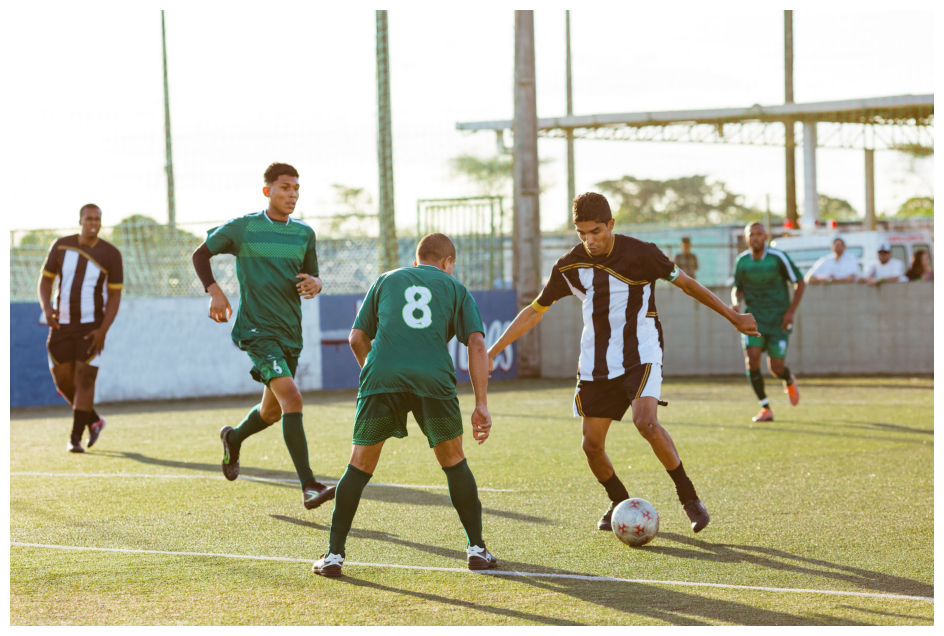

In [2]:
docs_dir = Path("docs")
docs_dir.mkdir(exist_ok=True)

image_path = docs_dir / "soccer.jpg"
image_url = "https://raw.githubusercontent.com/docudevs/python-examples/main/docs/soccer.jpg"

if not image_path.exists():
    urllib.request.urlretrieve(image_url, str(image_path))

if not image_path.exists():
    raise FileNotFoundError(f"Missing {image_path}")

image_bytes = image_path.read_bytes()
image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

print(f"Loaded {image_path}: {image.width} x {image.height}px, {len(image_bytes):,} bytes")

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()


## Define the Object Detection Schema and Prompt

The prompt asks the model for visible objects only. Bounding boxes should cover the visible extent of each object, not surrounding context.


In [3]:
class BoundingBox(BaseModel):
    left: float = Field(ge=0, le=1)
    top: float = Field(ge=0, le=1)
    right: float = Field(ge=0, le=1)
    bottom: float = Field(ge=0, le=1)


class DetectedObject(BaseModel):
    name: str = Field(description="Short human-readable name, such as 'ball' or 'player in red jersey'")
    object_type: str = Field(description="Category such as player, ball, goal, field marking, or equipment")
    description: str = Field(description="Brief visual description that helps identify the boxed object")
    bbox: BoundingBox = Field(description="Normalized bounding box in image coordinates")
    confidence: float = Field(ge=0, le=1)


class SoccerObjectDetection(BaseModel):
    scene_summary: str
    objects: list[DetectedObject]


def model_json_schema(model_type: type[BaseModel]) -> dict[str, Any]:
    if hasattr(model_type, "model_json_schema"):
        return model_type.model_json_schema()
    return model_type.schema()


def validate_model(model_type: type[BaseModel], payload: dict[str, Any]) -> BaseModel:
    if hasattr(model_type, "model_validate"):
        return model_type.model_validate(payload)
    return model_type.parse_obj(payload)


def dump_model(model: BaseModel) -> dict[str, Any]:
    if hasattr(model, "model_dump"):
        return model.model_dump()
    return model.dict()


object_detection_prompt = """
Detect the main visible objects in this soccer image.

Return visible objects only. Include soccer players, the ball, and any prominent sports equipment or field markings that are clearly visible. Do not invent objects that are hidden, implied, or outside the frame.

For each object:
- Use a concise source-image label in name.
- Set object_type to a short category such as player, ball, goal, field_marking, or equipment.
- Set bbox to the visible extent of the object only, not a group or surrounding whitespace.
- Use normalized coordinates from 0 to 1 in image space with origin at the top-left.
- Set confidence from 0 to 1.

Return JSON only. The JSON must match the provided schema.
""".strip()

schema_json = json.dumps(model_json_schema(SoccerObjectDetection))
print(schema_json[:800] + "...")


{"$defs": {"BoundingBox": {"properties": {"left": {"maximum": 1, "minimum": 0, "title": "Left", "type": "number"}, "top": {"maximum": 1, "minimum": 0, "title": "Top", "type": "number"}, "right": {"maximum": 1, "minimum": 0, "title": "Right", "type": "number"}, "bottom": {"maximum": 1, "minimum": 0, "title": "Bottom", "type": "number"}}, "required": ["left", "top", "right", "bottom"], "title": "BoundingBox", "type": "object"}, "DetectedObject": {"properties": {"name": {"description": "Short human-readable name, such as 'ball' or 'player in red jersey'", "title": "Name", "type": "string"}, "object_type": {"description": "Category such as player, ball, goal, field marking, or equipment", "title": "Object Type", "type": "string"}, "description": {"description": "Brief visual description that h...


## Run Object Detection


In [5]:
def to_plain(value: Any) -> Any:
    if hasattr(value, "to_dict"):
        return to_plain(value.to_dict())
    if hasattr(value, "model_dump"):
        return to_plain(value.model_dump())
    if isinstance(value, list):
        return [to_plain(item) for item in value]
    if isinstance(value, dict):
        return {key: to_plain(item) for key, item in value.items()}
    if hasattr(value, "__dict__") and value.__class__.__module__ != "builtins":
        return {key: to_plain(item) for key, item in vars(value).items()}
    return value


def extract_result_payload(value: Any) -> dict[str, Any]:
    plain = to_plain(value)
    if isinstance(plain, dict) and {"scene_summary", "objects"} <= set(plain):
        return plain
    if isinstance(plain, dict) and "result" in plain:
        result = plain["result"]
        if isinstance(result, str):
            return json.loads(result)
        if isinstance(result, dict):
            return result
    if isinstance(plain, str):
        return json.loads(plain)
    raise ValueError(f"Could not decode result payload from {type(value).__name__}: {plain!r}")


job_id = await client.submit_and_process_document(
    document=io.BytesIO(image_bytes),
    document_mime_type="image/jpeg",
    prompt=object_detection_prompt,
    schema=schema_json,
    ocr="PREMIUM",
    llm="DEFAULT",
)

raw_result = await client.wait_until_ready(job_id, timeout=600, poll_interval=5)
detection_payload = extract_result_payload(raw_result)
detection = validate_model(SoccerObjectDetection, detection_payload)

print(f"Job completed: {job_id}")
print(json.dumps(dump_model(detection), indent=2, ensure_ascii=False))


Job completed: 033d5cc7-6e98-40ba-aed7-42e6bd43c2e4
{
  "scene_summary": "A soccer match on a sunlit field with five visible players, one ball, and clear white field markings on artificial turf.",
  "objects": [
    {
      "name": "player in black-white jersey left",
      "object_type": "player",
      "description": "Player near the left edge wearing a black jersey with white vertical stripe and black shorts.",
      "bbox": {
        "left": 0.028,
        "top": 0.345,
        "right": 0.102,
        "bottom": 0.807
      },
      "confidence": 0.93
    },
    {
      "name": "player in green jersey left-center",
      "object_type": "player",
      "description": "Tall player in green kit running at left-center.",
      "bbox": {
        "left": 0.198,
        "top": 0.262,
        "right": 0.356,
        "bottom": 0.867
      },
      "confidence": 0.96
    },
    {
      "name": "player in green jersey number 8 center",
      "object_type": "player",
      "description": "Centr

## Draw Bounding Boxes on the Image


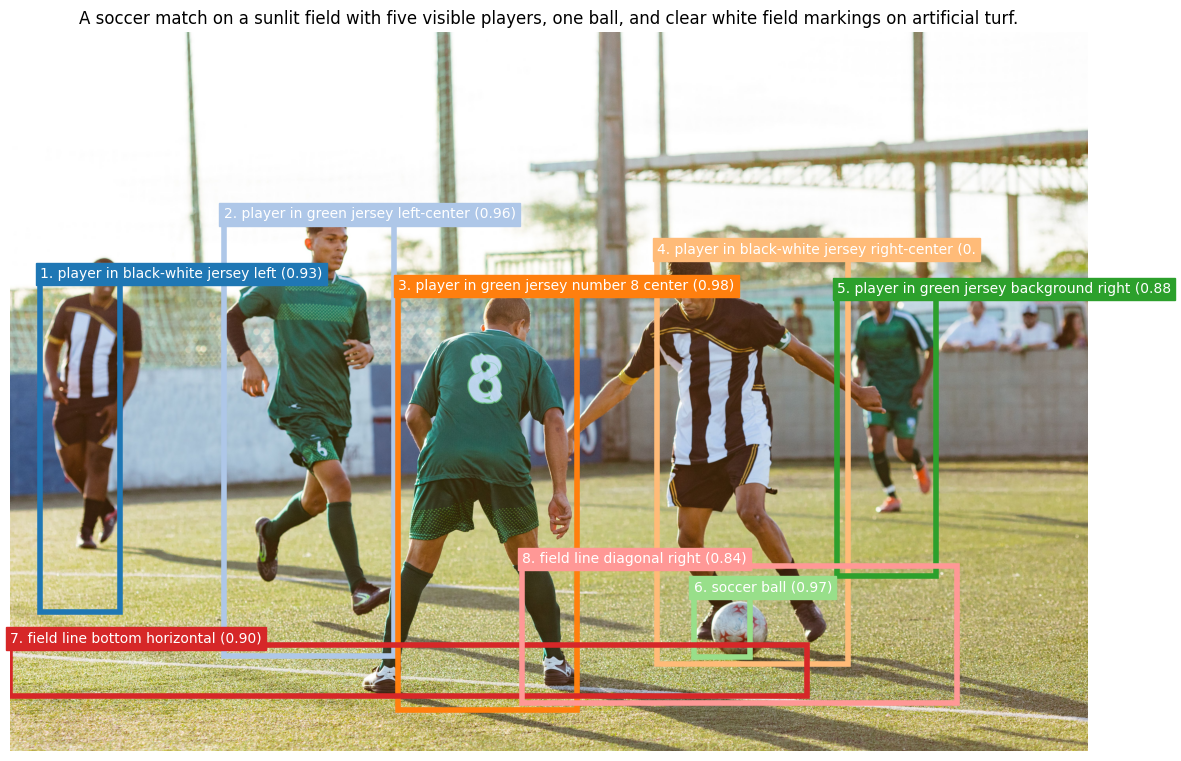

Overlay saved to outputs/soccer-object-detections.png


In [6]:
def clamp(value: float, minimum: float = 0.0, maximum: float = 1.0) -> float:
    return max(minimum, min(maximum, float(value)))


def bbox_to_pixels(bbox: BoundingBox, image_width: int, image_height: int) -> tuple[float, float, float, float]:
    left = clamp(bbox.left) * image_width
    top = clamp(bbox.top) * image_height
    right = clamp(bbox.right) * image_width
    bottom = clamp(bbox.bottom) * image_height
    return left, top, max(right - left, 1), max(bottom - top, 1)


def render_object_detections(base_image: Image.Image, result: SoccerObjectDetection) -> Path:
    colors = plt.cm.tab20.colors
    fig, ax = plt.subplots(figsize=(14, 14 * base_image.height / base_image.width))
    ax.imshow(base_image)

    for index, obj in enumerate(result.objects):
        left, top, width, height = bbox_to_pixels(obj.bbox, base_image.width, base_image.height)
        color = colors[index % len(colors)]
        ax.add_patch(Rectangle((left, top), width, height, fill=False, linewidth=4, edgecolor=color))
        label = f"{index + 1}. {obj.name} ({obj.confidence:.2f})"
        ax.text(
            left,
            max(top - 12, 16),
            label[:48],
            color="white",
            fontsize=10,
            bbox={"facecolor": color, "edgecolor": color, "pad": 3},
        )

    ax.set_title(result.scene_summary)
    ax.axis("off")
    output_path = Path("outputs") / "soccer-object-detections.png"
    fig.savefig(output_path, bbox_inches="tight", dpi=160)
    plt.show()
    return output_path


overlay_path = render_object_detections(image, detection)
print(f"Overlay saved to {overlay_path}")
